# Mental Health Analysis

This notebook contains code for complete analysis including:

- Loading Data
- Data Exploration / Preprocessing
- Fitting classifiers
- Evaluation

## Loading Data

In [27]:
from pathlib import Path
import pandas as pd
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [28]:
path = Path.cwd()
data_path = path / "Data" / "mental_heath_unbanlanced.csv"
df = pd.read_csv(data_path)
df.head()

,Unique_ID,text,status
0,0.0,oh my gosh,Anxiety
1,1.0,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2.0,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3.0,I've shifted my focus to something else but I'...,Anxiety
4,4.0,"I'm restless and restless, it's been a month n...",Anxiety


## Data Exploration

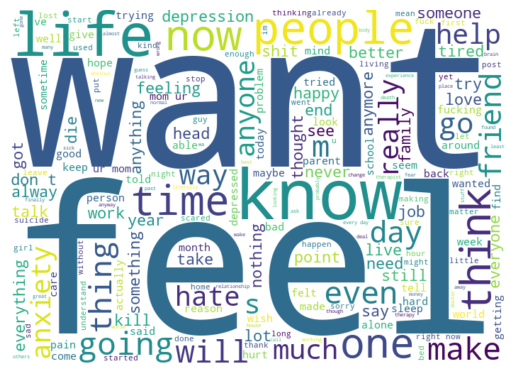

In [29]:
# Wordcloud
text = df['text'].str.cat() # Make the text into one large paragraph
wordcloud = WordCloud(width = 700, height = 500, background_color = 'white').generate(text) # Has built in filter for stop words

# Plot
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis('off')
plt.show()

In [30]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/maxmar/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

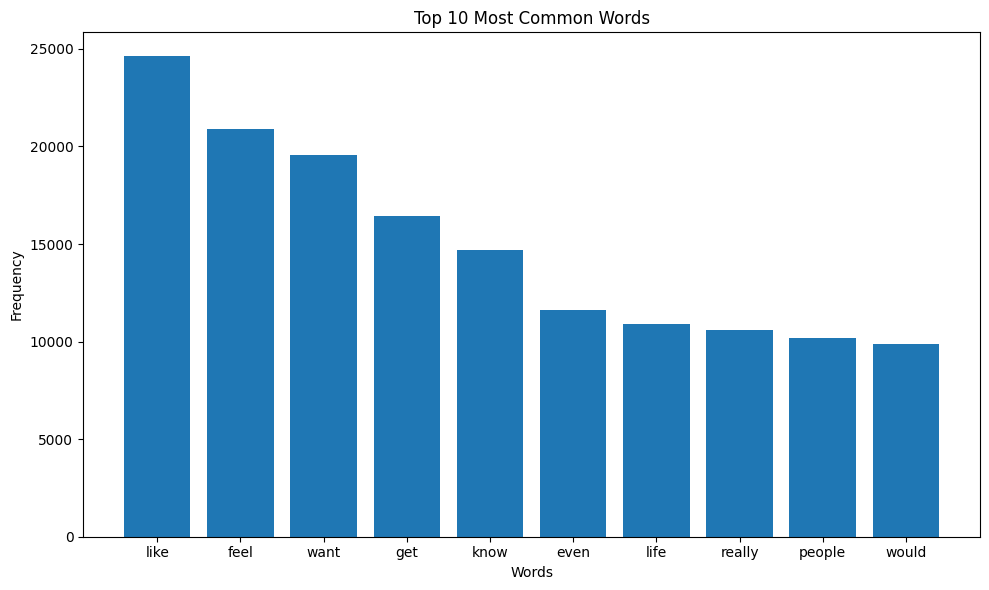

In [31]:
from collections import Counter
from nltk.corpus import stopwords

# Getting most frequent words
def plot_most_freq_words(text, stopwords):
    """
    Function that takes in raw text, cleans it and plots the most frequent words
    """
    
    # Preprocessing text
    text = text.lower()
    words = text.split()
    
    clean_words = []
    for word in words:
        if word not in stopwords:
            clean_words.append(word)

    # Count word frequencies
    word_counts = Counter(clean_words)    
    top_10_words = word_counts.most_common(10)
    word_labels_10 = [word for word, _ in top_10_words]
    word_counts_10 = [count for _, count in top_10_words]
    
    # Plot
    plt.figure(figsize = (10, 6))
    plt.bar(word_labels_10, word_counts_10)
    plt.xlabel('Words')
    plt.ylabel('Frequency')
    plt.title('Top 10 Most Common Words')
    plt.tight_layout()
    plt.show()
    
    # Return counts for all words
    return pd.DataFrame(word_counts.items(), columns = ['Word', 'Count'])

stop_words = set(stopwords.words('english'))    
freq_df = plot_most_freq_words(text, stop_words)

In [32]:
from sklearn.model_selection import train_test_split

Xtrain, Xtest, ytrain, ytest = train_test_split(df['text'], df['status'], test_size = 0.2, 
                                                    stratify = df['status'], random_state = 3)


In [33]:
df['status'].value_counts()

status
Normal        18391
Depression    14506
Suicidal      11212
Anxiety        5503
Name: count, dtype: int64

In [34]:
# map emotions
emotion_map = {'Anxiety': 0, 'Depression': 1, 'Normal': 2, 'Suicidal': 3}
ytrain = ytrain.map(emotion_map)
ytest = ytest.map(emotion_map)

## Dumb Baseline

In [35]:
counts = ytest.value_counts()

# dumb baseline where only the label with maximum frequency is predicted
max_count = counts[counts.index[0]]
total_count = ytest.count()

dumb_prediction_accr = max_count / total_count

print(dumb_prediction_accr)

0.37065403607779907


## Models

In [36]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import accuracy_score


def fit_predict(X_train, X_test, y_train, y_test, vectorizer, model):

    # Fit vectorizer
    X_train = vectorizer.fit_transform(X_train)
    X_test = vectorizer.transform(X_test)
   
    # Model
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)

    # Metrics
    cm = confusion_matrix(y_test, y_pred)
    recall = recall_score(y_test, y_pred, average = 'macro')
    precision = precision_score(y_test, y_pred, average = 'macro')
    accuracy = accuracy_score(y_test, y_pred)

    print('Recall: ', recall)
    print('Precision: ', precision)
    print('Accuracy: ', accuracy)

    return y_pred, y_proba, cm, recall, precision, accuracy

In [37]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

def plot_ovr_roc_curves(y_test, y_proba, classes, class_names, model_name):

    # Invert class_names from {name: number} to {number: name}
    class_names_inv = {v: k for k, v in class_names.items()}

    # Binarize y_test into shape (n_samples, n_classes)
    y_test_bin = label_binarize(y_test, classes=classes)

    fig, ax = plt.subplots(figsize=(8, 6))

    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
        roc_auc = auc(fpr, tpr)

        label_name = class_names_inv.get(cls, cls)  # fallback to cls if not found
        ax.plot(fpr, tpr, lw=2, label=f"{label_name} (AUC = {roc_auc:.2f})")

    # Random chance baseline
    ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random chance")

    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"One-vs-Rest ROC Curves - {model_name}")
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

## Predictions and Evaluations

In [38]:
# Call the models and vectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
import xgboost as xgb
from sklearn.feature_extraction.text import CountVectorizer

vect = CountVectorizer(stop_words = "english")

In [39]:
model_lr = LogisticRegression(random_state = 3, solver='lbfgs')
y_pred_lr, y_proba_lr, cm_lr, recall_lr, precision_lr, accuracy_lr = fit_predict(Xtrain, Xtest, ytrain, ytest, vect, 
                                                    model_lr)

Recall:  0.7334329903951804
Precision:  0.7408609519372265
Accuracy:  0.757533004131815


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


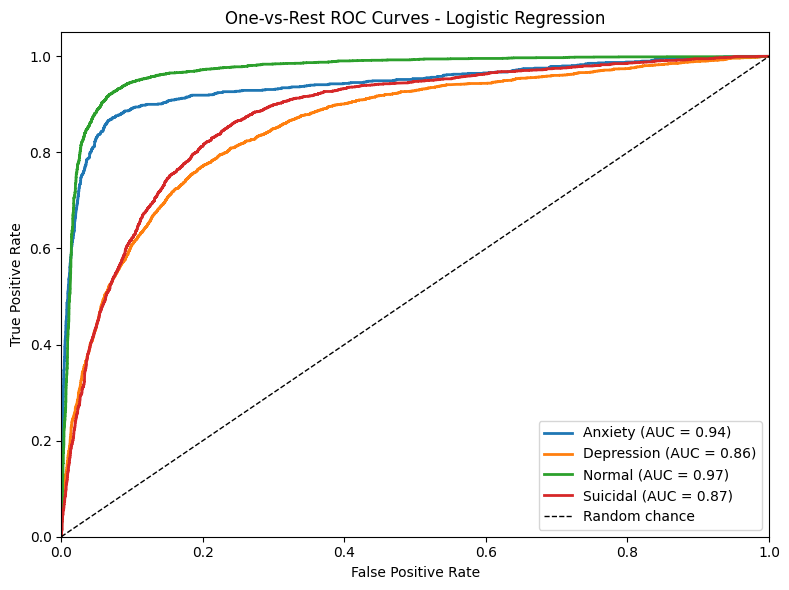

In [40]:
class_map = {'Anxiety': 0, 'Depression': 1, 'Normal': 2, 'Suicidal': 3}
plot_ovr_roc_curves(ytest, y_proba_lr, classes=model_lr.classes_, class_names = class_map, model_name = 'Logistic Regression')

In [41]:
model_nb = MultinomialNB()
y_pred_nb, y_proba_nb, cm_nb, recall_nb, precision_nb, accuracy_nb = fit_predict(Xtrain, Xtest, ytrain, ytest, vect,
                                                                      model_nb)

Recall:  0.689284396441838
Precision:  0.7061031811703143
Accuracy:  0.6913231885518493


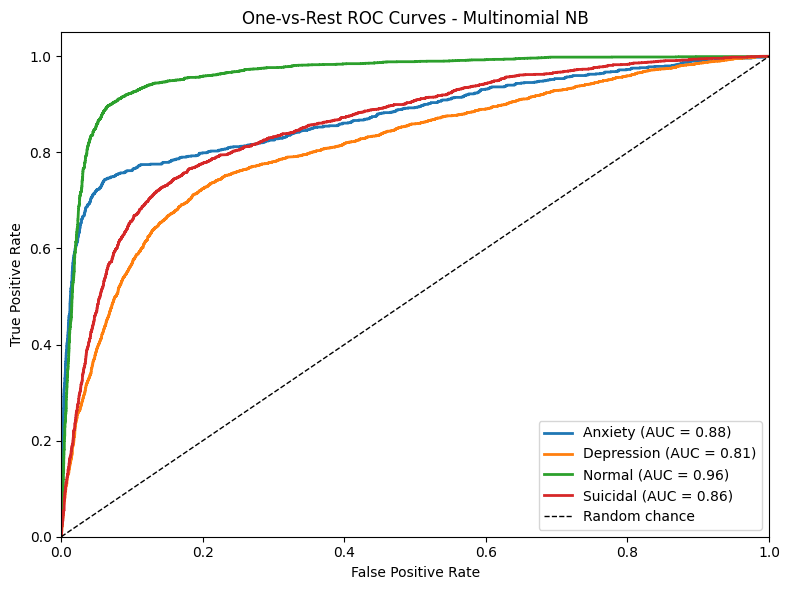

In [42]:
plot_ovr_roc_curves(ytest, y_proba_nb, classes=model_nb.classes_, class_names = class_map, model_name = 'Multinomial NB')

In [43]:
model_xgb = xgb.XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.1, eval_metric = 'mlogloss')
y_pred_xgb, y_proba_xgb, cm_xgb, recall_xgb, precision_xgb, accuracy_xgb = fit_predict(Xtrain, Xtest, ytrain, ytest, vect, 
                                                                          model_xgb)

Recall:  0.7063639245275943
Precision:  0.7374399160821856
Accuracy:  0.7435251436057644


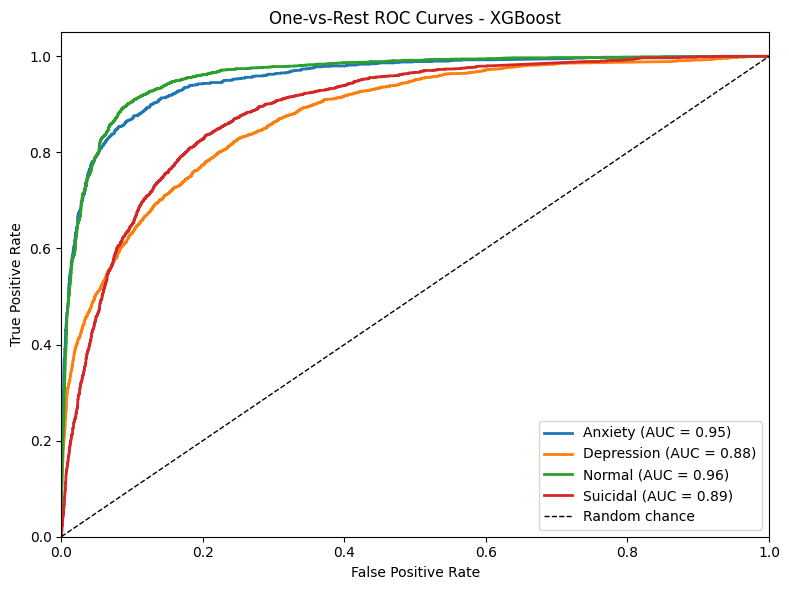

In [44]:
plot_ovr_roc_curves(ytest, y_proba_xgb, classes=model_xgb.classes_, class_names = class_map, model_name = 'XGBoost')

### Confusion Matrices

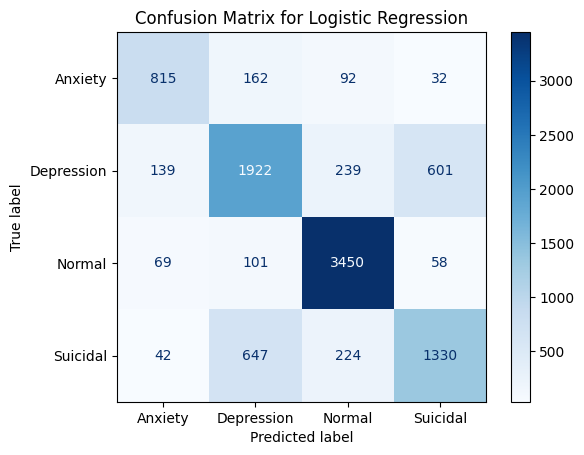

In [45]:
# Confusion Matrix for Logistic Regression
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=emotion_map)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

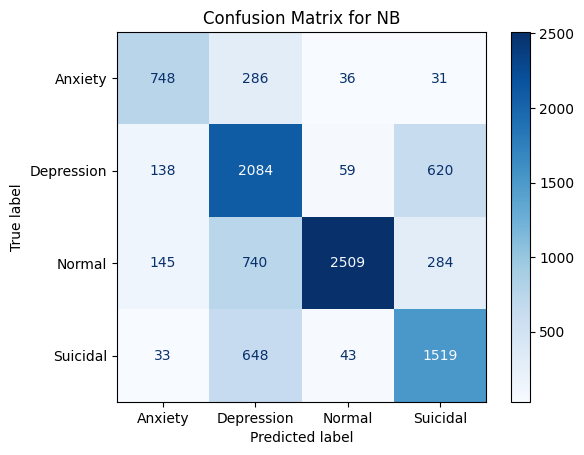

In [46]:
# Confusion Matrix for Naive Bayes
disp = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=emotion_map)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for NB')
plt.show()

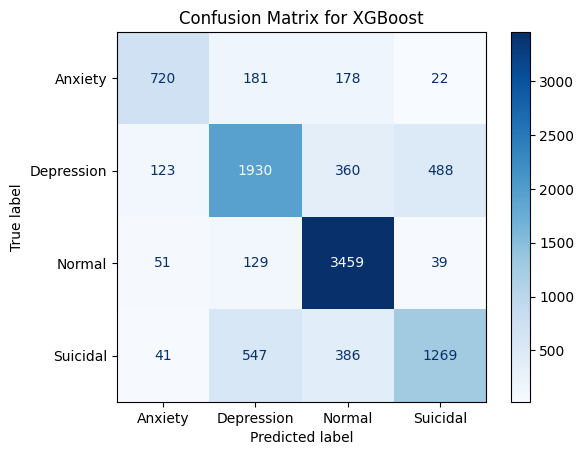

In [47]:
# Confusion Matrix for XGBoost
disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=emotion_map)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for XGBoost')
plt.show()